<a href="https://colab.research.google.com/github/Jay-103/DL-paper-Implementation/blob/main/LegalAI_Summarizer_Colab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ⚖️ LegalAI — Legal Document Summarizer (Google Colab)

Hybrid **extractive → abstractive** summarizer built on **LED (Longformer Encoder-Decoder)**, following the survey *"Deep Learning Techniques for Legal Text Summarization"* (transfer learning on pre-trained transformers, hybrid summarization, ROUGE evaluation).

**Workflow**
1. **Cell 1** installs dependencies and *restores a saved model zip* (local, Google Drive, or upload). If found, training is **skipped**.
2. Cells 2-3 configure and fine-tune (only runs if no zip was found).
3. Cell 4 saves the model as a **zip** and downloads it, so next time you only run Cell 1.
4. Cells 5-6 load the model and optionally evaluate with ROUGE.
5. Cell 7 is the **interactive UI** (upload PDF/TXT or paste text).

> Use a GPU runtime: *Runtime → Change runtime type → T4 GPU*.

In [1]:
# @title 1️⃣ Setup + restore saved model (skips training if a zip is found)
import os, sys, glob, shutil, subprocess, zipfile

def pip_install(*pkgs):
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", *pkgs], check=True)

pip_install("pymupdf", "rouge_score", "datasets", "accelerate", "sentencepiece")

# ---------------- settings ----------------
ZIP_NAME           = "legal_led_model.zip"
ZIP_LOCAL          = f"/content/{ZIP_NAME}"
DRIVE_ZIP          = f"/content/drive/MyDrive/{ZIP_NAME}"
SAVE_DIR           = "/content/legal_led_model"      # where a newly trained model is saved
USE_GOOGLE_DRIVE   = False   # True -> also look for / store the zip in your Google Drive
ASK_FOR_ZIP_UPLOAD = True    # True -> offer an upload box if no zip is found
# ------------------------------------------

MODEL_DIR     = None
SKIP_TRAINING = False

def unzip_model(zip_path):
    """Extract the zip and return the folder that contains config.json."""
    target = "/content/_restored_model"
    shutil.rmtree(target, ignore_errors=True)
    os.makedirs(target)
    with zipfile.ZipFile(zip_path) as z:
        z.extractall(target)
    hits = glob.glob(f"{target}/**/config.json", recursive=True)
    if not hits:
        raise FileNotFoundError("config.json not found inside the zip - not a valid saved model.")
    return os.path.dirname(hits[0])

zip_found = None

if os.path.exists(ZIP_LOCAL):
    zip_found = ZIP_LOCAL

if zip_found is None and USE_GOOGLE_DRIVE:
    from google.colab import drive
    drive.mount("/content/drive")
    if os.path.exists(DRIVE_ZIP):
        zip_found = DRIVE_ZIP

if zip_found is None and ASK_FOR_ZIP_UPLOAD:
    print("📦 No saved model found. Upload a model .zip now, or cancel to train from scratch.")
    try:
        from google.colab import files
        uploaded = files.upload()
        zips = [n for n in uploaded if n.lower().endswith(".zip")]
        if zips:
            shutil.move(zips[0], ZIP_LOCAL)
            zip_found = ZIP_LOCAL
    except Exception as e:
        print("Upload skipped:", e)

if zip_found:
    MODEL_DIR = unzip_model(zip_found)
    SKIP_TRAINING = True
    print(f"✅ Model restored from {zip_found}\n   -> {MODEL_DIR}\n⏭️  TRAINING WILL BE SKIPPED (Cell 3).")
else:
    print("ℹ️ No saved model - Cell 3 will fine-tune one (then Cell 4 saves it as a zip).")

import torch
print("GPU:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "none (CPU - training will be very slow)")


📦 No saved model found. Upload a model .zip now, or cancel to train from scratch.


ℹ️ No saved model - Cell 3 will fine-tune one (then Cell 4 saves it as a zip).
GPU: Tesla T4


## 2️⃣ Training configuration
Only used when no zip was restored. Follows the paper's transfer-learning approach: start from a pre-trained LED and fine-tune on (document, summary) pairs.

In [2]:
# @title 2️⃣ Configuration (training data + hyper-parameters)
BASE_MODEL   = "allenai/led-base-16384"   # pre-trained LED to fine-tune (paper: transfer learning)

# Data: default is BillSum (US legislation + human summaries). Or use your own CSV.
DATASET_NAME = "FiscalNote/billsum"
CUSTOM_CSV   = None                       # e.g. "/content/my_cases.csv"
TEXT_COL     = "text"
SUMMARY_COL  = "summary"

N_TRAIN      = 600      # number of training pairs (raise for better quality)
N_EVAL       = 20       # held-out pairs for ROUGE
EPOCHS       = 2
LEARNING_RATE= 3e-5
MAX_INPUT    = 4096     # lower to 2048 if you hit GPU out-of-memory
MAX_TARGET   = 384
BATCH_SIZE   = 1
GRAD_ACCUM   = 8

def load_corpus():
    """Deterministic (shuffled, seed=42) corpus; last N_EVAL rows are the held-out set."""
    from datasets import load_dataset, Dataset
    if CUSTOM_CSV:
        import pandas as pd
        df = pd.read_csv(CUSTOM_CSV).dropna(subset=[TEXT_COL, SUMMARY_COL])
        ds = Dataset.from_pandas(df[[TEXT_COL, SUMMARY_COL]].reset_index(drop=True))
    else:
        ds = load_dataset(DATASET_NAME, split=f"train[:{N_TRAIN + N_EVAL + 300}]")
    ds = ds.shuffle(seed=42)
    return ds.select(range(min(len(ds), N_TRAIN + N_EVAL)))

print("Config OK. Skip training:", SKIP_TRAINING)


Config OK. Skip training: False


In [3]:
# @title 3️⃣ Fine-tune LED (auto-skipped when a model zip was restored)
if SKIP_TRAINING:
    print("⏭️ Training skipped - using the restored model.")
else:
    import torch
    from transformers import (AutoTokenizer, AutoModelForSeq2SeqLM,
                              Seq2SeqTrainer, Seq2SeqTrainingArguments)

    tok   = AutoTokenizer.from_pretrained(BASE_MODEL)
    model = AutoModelForSeq2SeqLM.from_pretrained(BASE_MODEL)
    model.config.use_cache = False

    corpus   = load_corpus()
    train_ds = corpus.select(range(len(corpus) - N_EVAL))
    print(f"Training pairs: {len(train_ds)} | held-out: {N_EVAL}")

    def preprocess(batch):
        x = tok(batch[TEXT_COL], max_length=MAX_INPUT, truncation=True)
        y = tok(text_target=batch[SUMMARY_COL], max_length=MAX_TARGET, truncation=True)
        x["labels"] = y["input_ids"]
        return x

    tokenized = train_ds.map(preprocess, batched=True, remove_columns=train_ds.column_names)

    def collate(features):
        """Pad a batch and add LED's global attention on the first token."""
        n_in  = max(len(f["input_ids"]) for f in features)
        n_out = max(len(f["labels"]) for f in features)
        ids, mask, labels = [], [], []
        for f in features:
            pad_in = n_in - len(f["input_ids"])
            ids.append(f["input_ids"] + [tok.pad_token_id] * pad_in)
            mask.append(f["attention_mask"] + [0] * pad_in)
            labels.append(f["labels"] + [-100] * (n_out - len(f["labels"])))
        ids = torch.tensor(ids)
        glob_mask = torch.zeros_like(ids)
        glob_mask[:, 0] = 1
        return {"input_ids": ids, "attention_mask": torch.tensor(mask),
                "global_attention_mask": glob_mask, "labels": torch.tensor(labels)}

    args = Seq2SeqTrainingArguments(
        output_dir="/content/_trainer_tmp",
        per_device_train_batch_size=BATCH_SIZE,
        gradient_accumulation_steps=GRAD_ACCUM,
        num_train_epochs=EPOCHS,
        learning_rate=LEARNING_RATE,
        warmup_steps=10,
        fp16=torch.cuda.is_available(),
        gradient_checkpointing=True,
        logging_steps=10,
        save_strategy="no",
        report_to="none",
        remove_unused_columns=False,
    )
    trainer = Seq2SeqTrainer(model=model, args=args, train_dataset=tokenized, data_collator=collate)
    trainer.train()

    model.config.use_cache = True
    os.makedirs(SAVE_DIR, exist_ok=True)
    model.save_pretrained(SAVE_DIR)
    tok.save_pretrained(SAVE_DIR)
    MODEL_DIR = SAVE_DIR
    del model, trainer
    torch.cuda.empty_cache()
    print("✅ Training finished. Model saved to", SAVE_DIR)


config.json:   0%|          | 0.00/1.09k [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/27.0 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/899k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/772 [00:00<?, ?B/s]

...

[transformers] Input ids are automatically padded from 3966 to 4096 to be a multiple of `config.attention_window`: 1024
[transformers] Input ids are automatically padded from 1647 to 2048 to be a multiple of `config.attention_window`: 1024
[transformers] Input ids are automatically padded from 3693 to 4096 to be a multiple of `config.attention_window`: 1024
[transformers] Input ids are automatically padded from 1496 to 2048 to be a multiple of `config.attention_window`: 1024
[transformers] Input ids are automatically padded from 3289 to 4096 to be a multiple of `config.attention_window`: 1024
[transformers] Input ids are automatically padded from 1724 to 2048 to be a multiple of `config.attention_window`: 1024
[transformers] Input ids are automatically padded from 3083 to 4096 to be a multiple of `config.attention_window`: 1024


Step,Training Loss
10,24.183269
20,19.033936
30,17.111842
40,17.498782
50,15.868399
60,16.743622
70,15.444160
80,13.878413
90,13.527489
100,12.438539


[transformers] Input ids are automatically padded from 2652 to 3072 to be a multiple of `config.attention_window`: 1024
[transformers] Input ids are automatically padded from 3605 to 4096 to be a multiple of `config.attention_window`: 1024
[transformers] Input ids are automatically padded from 2865 to 3072 to be a multiple of `config.attention_window`: 1024
[transformers] Input ids are automatically padded from 3953 to 4096 to be a multiple of `config.attention_window`: 1024
[transformers] Input ids are automatically padded from 3357 to 4096 to be a multiple of `config.attention_window`: 1024
[transformers] Input ids are automatically padded from 3013 to 3072 to be a multiple of `config.attention_window`: 1024
[transformers] Input ids are automatically padded from 2298 to 3072 to be a multiple of `config.attention_window`: 1024
[transformers] Input ids are automatically padded from 1918 to 2048 to be a multiple of `config.attention_window`: 1024
[transformers] Input ids are automatical

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

✅ Training finished. Model saved to /content/legal_led_model


## 4️⃣ Save the model as a ZIP
Run this once after training. Next session, just put the zip in `/content` (or Drive / upload box) and Cell 1 will restore it and skip training.

In [4]:
# @title 4️⃣ Save model as ZIP + download
import shutil, os
assert MODEL_DIR and os.path.exists(os.path.join(MODEL_DIR, "config.json")), \
    "No model available to save - run Cell 3 (or restore a zip in Cell 1) first."

zip_path = shutil.make_archive(ZIP_LOCAL[:-4], "zip", root_dir=MODEL_DIR)
print(f"📦 Saved: {zip_path}  ({os.path.getsize(zip_path)/1e6:.0f} MB)")

if USE_GOOGLE_DRIVE:
    os.makedirs(os.path.dirname(DRIVE_ZIP), exist_ok=True)
    shutil.copy(zip_path, DRIVE_ZIP)
    print("☁️ Copied to Google Drive:", DRIVE_ZIP)

try:
    from google.colab import files
    files.download(zip_path)
except Exception as e:
    print("Download skipped:", e)


📦 Saved: /content/legal_led_model.zip  (588 MB)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## 5️⃣ Load model + summarization pipeline
Ported from `app.py` / `document_processor.py` / `summarizer.py`, unified into one pipeline, with the paper's **hybrid extractive → abstractive** strategy for documents longer than the model's input window.

In [5]:
# @title 5️⃣ Load model + helper functions
import os, re, time
import torch
import fitz  # PyMuPDF
from transformers import AutoTokenizer, AutoModelForSeq2SeqLM

FALLBACK_MODEL   = "Yashaswat/indian-legal-led-base"   # used only if no local model exists
MAX_INPUT_TOKENS = 4096
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

_tokenizer, _model = None, None

def get_model():
    global _tokenizer, _model
    if _model is None:
        has_local = MODEL_DIR and os.path.exists(os.path.join(MODEL_DIR, "config.json"))
        src = MODEL_DIR if has_local else FALLBACK_MODEL
        print("Loading model from:", src)
        _tokenizer = AutoTokenizer.from_pretrained(src)
        _model = AutoModelForSeq2SeqLM.from_pretrained(src).to(DEVICE).eval()
    return _tokenizer, _model

# ---------------- document processing ----------------
def extract_text(filename, data: bytes):
    if filename.lower().endswith(".pdf"):
        doc = fitz.open(stream=data, filetype="pdf")
        try:
            pages = [p.get_text() for p in doc if p.get_text().strip()]
        finally:
            doc.close()
        text = "\n\n".join(pages)
        if not text.strip():
            raise ValueError("No extractable text (scanned PDF?). OCR is needed for image-only PDFs.")
        return text
    return data.decode("utf-8", errors="ignore")

def clean_text(text):
    return "\n".join(l.strip() for l in text.splitlines() if l.strip())

def get_document_stats(text):
    return {"words": len(text.split()), "characters": len(text),
            "sentences": len(re.findall(r"[.!?]+(?=\s|$)", text))}

def detect_legal_sections(text):
    patterns = [
        r"\bIPC\s*(?:Section\s*)?(\d+[A-Za-z]?)\b",
        r"\bSection\s*(\d+[A-Za-z]?)\s*(?:of\s+the\s+)?(?:IPC|Indian Penal Code)\b",
        r"\bSec\.?\s*(\d+[A-Za-z]?)\b",
        r"\bBNS\s*(?:Section\s*)?(\d+[A-Za-z]?)\b",
        r"\bSection\s*(\d+[A-Za-z]?)\s*(?:of\s+the\s+)?(?:BNS|Bharatiya Nyaya Sanhita)\b",
    ]
    found = set()
    for p in patterns:
        found.update(re.findall(p, text, flags=re.IGNORECASE))
    return sorted(found, key=lambda x: int(re.sub(r"\D", "", x) or 0))

def split_sentences(text):
    text = re.sub(r"\s+", " ", text).strip()
    if not text:
        return []
    return [s.strip() for s in re.split(r"(?<=[.!?])\s+", text) if len(s.strip()) > 25]

# ---------------- extractive scoring (TF + legal keywords + position) ----------------
STOP = {"that","this","with","from","have","been","were","your","which","shall","would",
        "there","their","they","such","will"}
LEGAL_TERMS = ["notice","legal notice","demand","agreement","contract","payment","amount",
    "breach","default","liability","claim","consequence","proceedings","court","law","section",
    "ipc","bns","indian contract act","legal action","repay","refund","compensation",
    "response","within","held","judgment","appeal","petitioner","respondent","order"]

def score_sentences(sentences, full_text):
    freq = {}
    for w in re.findall(r"\b[a-zA-Z]{3,}\b", full_text.lower()):
        if w not in STOP:
            freq[w] = freq.get(w, 0) + 1
    max_f = max(freq.values()) if freq else 1
    n, scores = len(sentences), []
    for i, s in enumerate(sentences):
        low = s.lower()
        ws = re.findall(r"\b[a-zA-Z]{3,}\b", low)
        if not ws:
            scores.append(0.0); continue
        f = sum(freq.get(w, 0) for w in ws) / len(ws)
        k = sum(2.5 for t in LEGAL_TERMS if t in low)
        p = (3 if i < 3 else 0) + (2 if i > n - 4 else 0)   # paper [13]: opening/closing sentences matter
        scores.append((f / max_f) * 4 + k + p)
    return scores

def extractive_legal_summary(text, target_sentences=7):
    sents = split_sentences(text)
    if not sents:
        return text[:1500]
    if len(sents) <= target_sentences:
        return " ".join(sents)
    scores = score_sentences(sents, text)
    top = sorted(sorted(range(len(sents)), key=lambda i: scores[i], reverse=True)[:target_sentences])
    return " ".join(sents[i] for i in top)

def compress_to_budget(text, token_budget):
    """Extractive stage of the hybrid pipeline: keep the best sentences that fit the budget, in order."""
    tokenizer, _ = get_model()
    sents = split_sentences(text)
    scores = score_sentences(sents, text)
    lens = [len(x) for x in tokenizer(sents, add_special_tokens=False)["input_ids"]]
    chosen, used = [], 0
    for i in sorted(range(len(sents)), key=lambda i: scores[i], reverse=True):
        if used + lens[i] <= token_budget:
            chosen.append(i); used += lens[i]
    return " ".join(sents[i] for i in sorted(chosen))

def summary_is_bad(summary, source):
    if not summary:
        return True
    low = summary.lower()
    bad = ["unclassified","advocate's letterhead","[full name]","[bar council no.]","[office address]",
           "[phone]","[email]","dear sir/madam","dear sir or madam","yours faithfully","hereby certify"]
    if any(b in low for b in bad):
        return True
    words = low.split()
    if len(words) >= 30:
        chunks = [" ".join(words[i:i+6]) for i in range(len(words) - 5)]
        if len(chunks) - len(set(chunks)) >= 3:
            return True
    if len(source.split()) > 500 and len(words) < 25:
        return True
    return False

# ---------------- abstractive generation ----------------
def abstractive_summary(text, max_new_tokens=384, min_new_tokens=80):
    tokenizer, model = get_model()
    enc = tokenizer(text, return_tensors="pt", max_length=MAX_INPUT_TOKENS, truncation=True)
    ids  = enc["input_ids"].to(DEVICE)
    mask = enc["attention_mask"].to(DEVICE)
    gmask = torch.zeros_like(ids); gmask[:, 0] = 1            # LED global attention on first token
    cap = 512 if DEVICE.type == "cuda" else 220               # keep CPU runs tolerable
    max_new = min(max_new_tokens, cap)
    min_new = min(min_new_tokens, max(20, max_new - 30))
    with torch.inference_mode():
        out = model.generate(input_ids=ids, attention_mask=mask, global_attention_mask=gmask,
                             max_new_tokens=max_new, min_new_tokens=min_new,
                             num_beams=4 if DEVICE.type == "cuda" else 2,
                             no_repeat_ngram_size=4, repetition_penalty=1.12,
                             length_penalty=1.0, do_sample=False, early_stopping=True)
    return re.sub(r"\s+", " ", tokenizer.decode(out[0], skip_special_tokens=True)).strip()

METHODS = ["Hybrid (recommended)", "Abstractive only", "Extractive only"]

def summarize_document(text, method=METHODS[0], max_new_tokens=384, min_new_tokens=80):
    """Returns (summary, note)."""
    if method == "Extractive only":
        return extractive_legal_summary(text, 7), "Extractive (TF + legal keywords + position)."
    tokenizer, _ = get_model()
    n_tok = len(tokenizer(text, add_special_tokens=False)["input_ids"])
    note, model_input = "Abstractive (LED).", text
    if n_tok > MAX_INPUT_TOKENS - 8:
        if method.startswith("Hybrid"):
            model_input = compress_to_budget(text, MAX_INPUT_TOKENS - 64)
            note = f"Hybrid: extractive pre-selection ({n_tok:,} -> ~{MAX_INPUT_TOKENS:,} tokens), then abstractive LED."
        else:
            note = f"Abstractive LED on the first {MAX_INPUT_TOKENS:,} of {n_tok:,} tokens (rest truncated)."
    summary = abstractive_summary(model_input, max_new_tokens, min_new_tokens)
    if summary_is_bad(summary, text):
        return extractive_legal_summary(text, 7), "Quality guard triggered (unreliable LED output) -> extractive fallback."
    return summary, note

get_model()
print("✅ Ready on", DEVICE)


Loading model from: /content/legal_led_model


Loading weights:   0%|          | 0/296 [00:00<?, ?it/s]

✅ Ready on cuda


## 6️⃣ (Optional) Evaluate with ROUGE
The paper's primary automatic metric. Scores the model on held-out pairs from the training corpus.

In [6]:
# @title 6️⃣ ROUGE evaluation on held-out data (optional)
from rouge_score import rouge_scorer
import numpy as np

corpus = load_corpus()
held   = corpus.select(range(max(0, len(corpus) - N_EVAL), len(corpus)))
scorer = rouge_scorer.RougeScorer(["rouge1", "rouge2", "rougeL"], use_stemmer=True)

rows = []
for i, ex in enumerate(held):
    pred, _ = summarize_document(ex[TEXT_COL], METHODS[0], 256, 50)
    s = scorer.score(ex[SUMMARY_COL], pred)
    rows.append([s["rouge1"].fmeasure, s["rouge2"].fmeasure, s["rougeL"].fmeasure])
    print(f"  {i+1}/{len(held)} done", end="\r")

m = np.mean(rows, axis=0)
print(f"\nROUGE-1 {m[0]:.3f} | ROUGE-2 {m[1]:.3f} | ROUGE-L {m[2]:.3f}   (n={len(held)})")


[transformers] Input ids are automatically padded from 3975 to 4096 to be a multiple of `config.attention_window`: 1024
[transformers] Input ids are automatically padded from 1678 to 2048 to be a multiple of `config.attention_window`: 1024


[transformers] Input ids are automatically padded from 2645 to 3072 to be a multiple of `config.attention_window`: 1024


[transformers] Input ids are automatically padded from 3054 to 3072 to be a multiple of `config.attention_window`: 1024


[transformers] Input ids are automatically padded from 2051 to 3072 to be a multiple of `config.attention_window`: 1024


[transformers] Input ids are automatically padded from 2157 to 3072 to be a multiple of `config.attention_window`: 1024


...

[transformers] Input ids are automatically padded from 3301 to 4096 to be a multiple of `config.attention_window`: 1024


[transformers] Input ids are automatically padded from 3472 to 4096 to be a multiple of `config.attention_window`: 1024


[transformers] Input ids are automatically padded from 3006 to 3072 to be a multiple of `config.attention_window`: 1024


[transformers] Input ids are automatically padded from 2229 to 3072 to be a multiple of `config.attention_window`: 1024


  20/20 done
ROUGE-1 0.392 | ROUGE-2 0.248 | ROUGE-L 0.312   (n=20)


## 7️⃣ Interactive summarizer
Choose **Upload file** (PDF/TXT) or **Paste text**, tune the options, and press **Summarize**. You can change the input and press the button again as many times as you like.

In [7]:
# @title 7️⃣ Interactive UI
import html as _html, time
import ipywidgets as W
from IPython.display import display, HTML, clear_output

style = {"description_width": "130px"}
wide  = W.Layout(width="600px")

input_mode = W.ToggleButtons(options=["Upload file", "Paste text"], description="Input:", style=style)
uploader   = W.FileUpload(accept=".pdf,.txt", multiple=False, description="Choose PDF / TXT")
text_area  = W.Textarea(placeholder="Paste the legal document text here...",
                        layout=W.Layout(width="100%", height="200px"))
method     = W.Dropdown(options=METHODS, value=METHODS[0], description="Method:", style=style, layout=wide)
max_len    = W.IntSlider(value=384, min=128, max=1024, step=64, description="Max summary tokens:", style=style, layout=wide)
min_len    = W.IntSlider(value=80, min=30, max=300, step=10, description="Min summary tokens:", style=style, layout=wide)
reference  = W.Textarea(placeholder="(Optional) paste a human reference summary to get ROUGE scores",
                        layout=W.Layout(width="100%", height="70px"))
dl_check   = W.Checkbox(value=False, description="Download summary as .txt", indent=False)
run_btn    = W.Button(description="Summarize", button_style="primary", icon="gavel",
                      layout=W.Layout(width="200px", height="40px"))
out        = W.Output()

def _toggle(_=None):
    is_upload = input_mode.value == "Upload file"
    uploader.layout.display  = "" if is_upload else "none"
    text_area.layout.display = "none" if is_upload else ""
input_mode.observe(_toggle, names="value"); _toggle()

def _read_input():
    if input_mode.value == "Paste text":
        return "pasted_text.txt", text_area.value.encode("utf-8")
    v = uploader.value
    if not v:
        raise ValueError("Please choose a PDF or TXT file first.")
    item = list(v.values())[0] if isinstance(v, dict) else v[0]      # ipywidgets 7 vs 8
    name = item.get("name") or item.get("metadata", {}).get("name", "upload.txt")
    return name, bytes(item["content"])

def _card(label, value):
    return (f"<div style='flex:1;min-width:120px;padding:12px;border:1px solid #8884;border-radius:10px'>"
            f"<div style='font-size:11px;opacity:.7;text-transform:uppercase'>{label}</div>"
            f"<div style='font-size:22px;font-weight:700'>{value}</div></div>")

def _on_click(_):
    with out:
        clear_output()
        try:
            name, data = _read_input()
            text = clean_text(extract_text(name, data))
            if len(text.split()) < 30:
                raise ValueError("The document is too short to summarize (need at least ~30 words).")
            stats = get_document_stats(text)
            sections = detect_legal_sections(text)
            lo = min(min_len.value, max_len.value - 20)

            t0 = time.time()
            print("⏳ Summarizing...")
            summary, note = summarize_document(text, method.value, max_len.value, lo)
            elapsed = time.time() - t0
            clear_output()

            s_words = len(summary.split())
            reduction = max(0, round((1 - s_words / max(1, stats["words"])) * 100))
            display(HTML("<div style='display:flex;gap:10px;flex-wrap:wrap;margin:8px 0'>"
                + _card("Original words", f"{stats['words']:,}") + _card("Summary words", f"{s_words:,}")
                + _card("Reduction", f"{reduction}%") + _card("Time", f"{elapsed:.1f}s") + "</div>"))
            display(HTML(f"<h3>✦ Summary</h3><div style='padding:14px;border:1px solid #8886;"
                         f"border-radius:10px;line-height:1.7'>{_html.escape(summary)}</div>"
                         f"<p style='opacity:.7;font-size:12px'>{_html.escape(note)}</p>"))

            if sections:
                tags = "".join(f"<span style='display:inline-block;margin:3px;padding:5px 10px;border-radius:8px;"
                               f"border:1px solid #6366f155;background:#6366f11a'>Section {_html.escape(s)}</span>"
                               for s in sections)
                display(HTML(f"<h4>⚖️ Detected legal sections</h4>{tags}"))
            else:
                display(HTML("<p>⚖️ No explicit IPC/BNS section numbers detected.</p>"))

            if reference.value.strip():
                from rouge_score import rouge_scorer
                sc = rouge_scorer.RougeScorer(["rouge1", "rouge2", "rougeL"], use_stemmer=True) \
                        .score(reference.value.strip(), summary)
                display(HTML("<h4>📊 ROUGE vs reference</h4>" + " &nbsp;|&nbsp; ".join(
                    f"<b>{k.upper()}</b> F1 {v.fmeasure:.3f}" for k, v in sc.items())))

            display(HTML("<p style='opacity:.6;font-size:12px'>Summaries are indicative only. "
                         "Have a qualified legal professional verify important information.</p>"))

            if dl_check.value:
                with open("/content/legal_summary.txt", "w") as f:
                    f.write(summary)
                from google.colab import files
                files.download("/content/legal_summary.txt")
        except Exception as e:
            clear_output()
            print("❌", e)

run_btn.on_click(_on_click)

display(W.VBox([
    W.HTML("<h2>⚖️ LegalAI - Legal Document Summarizer</h2>"),
    input_mode, uploader, text_area, method, max_len, min_len,
    W.HTML("<b>Reference summary (optional):</b>"), reference, dl_check, run_btn, out,
]))


ℹ️ No training_log.json found - skipping training curves.


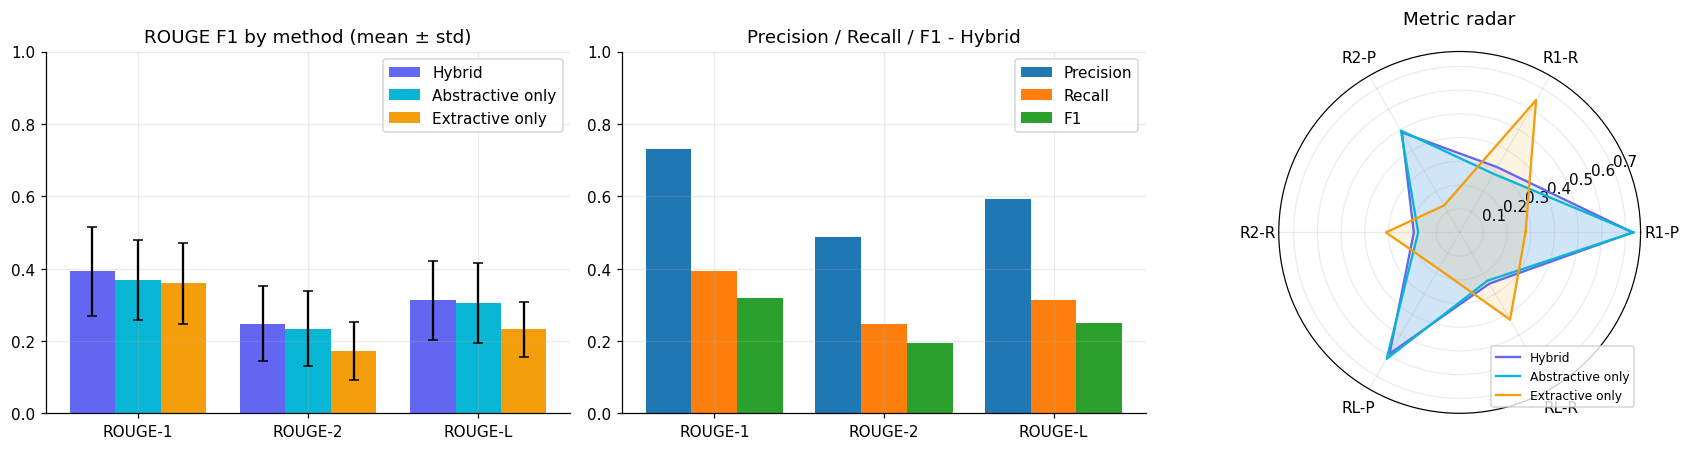

/tmp/ipykernel_855/1804877684.py:116: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax[1].boxplot([df[df.method == m].rougeL_f for m in COMPARE], labels=[short(m) for m in COMPARE], showmeans=True)


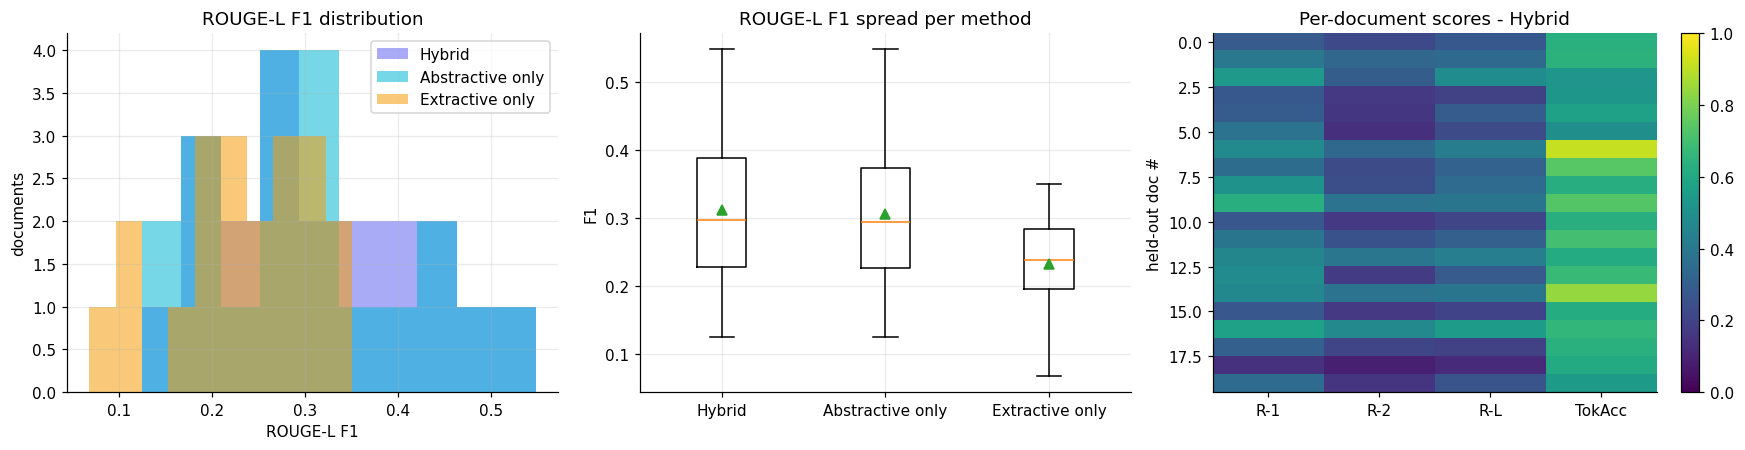

/tmp/ipykernel_855/1804877684.py:146: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  eff = df.groupby("method").apply(lambda d: d.rougeL_f.mean() / max(d.time_s.mean(), 1e-3)).loc[COMPARE]


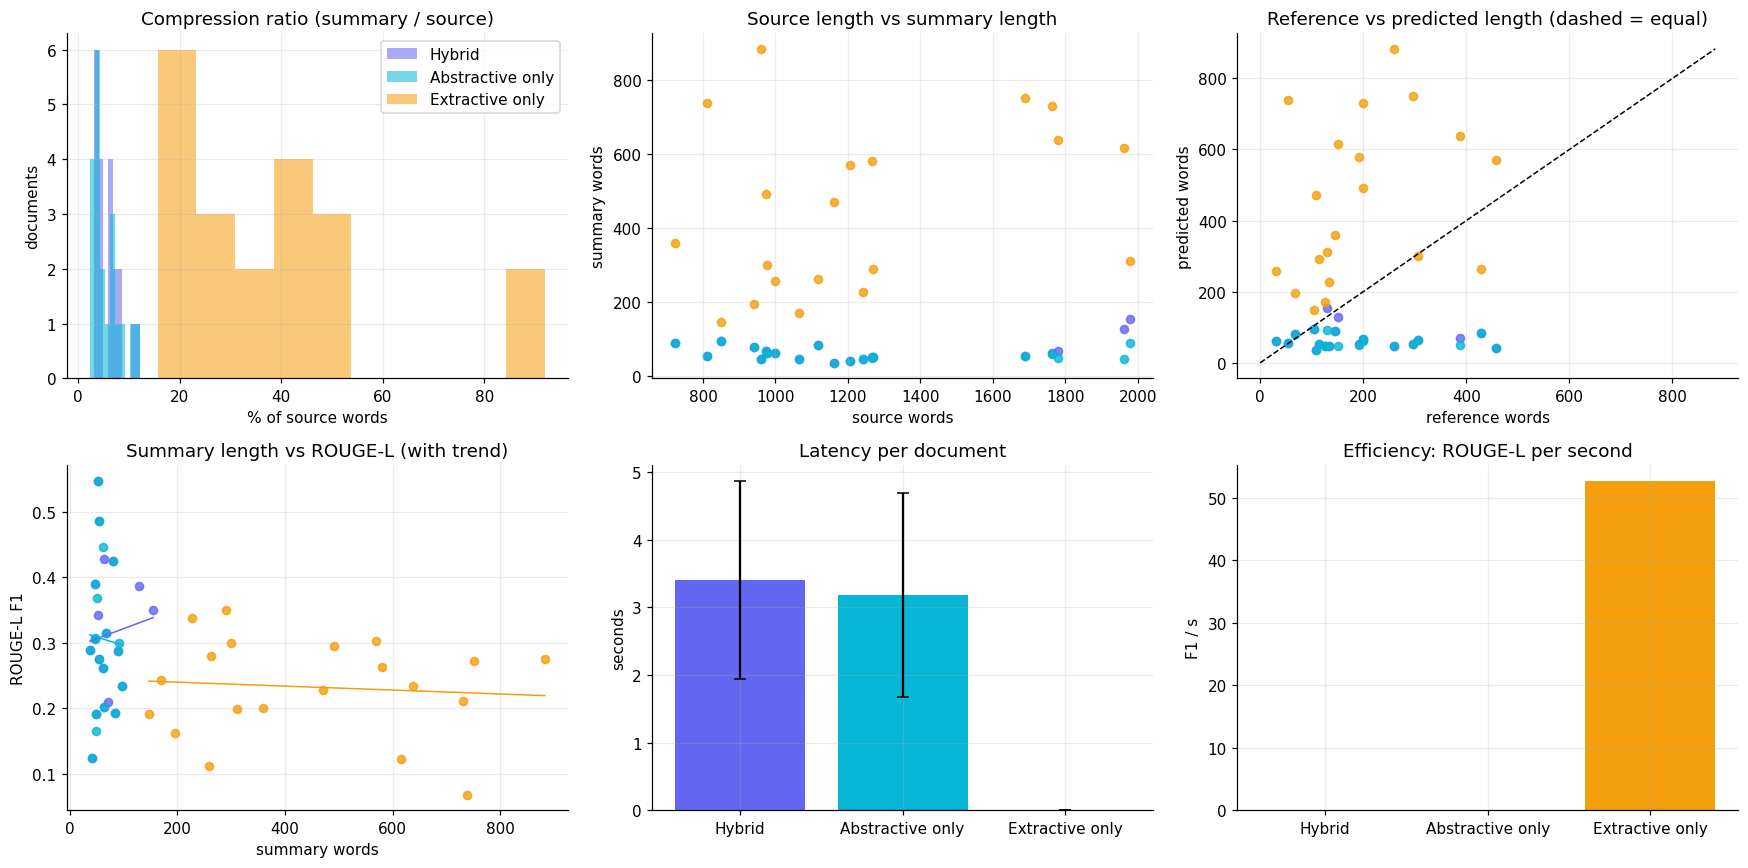

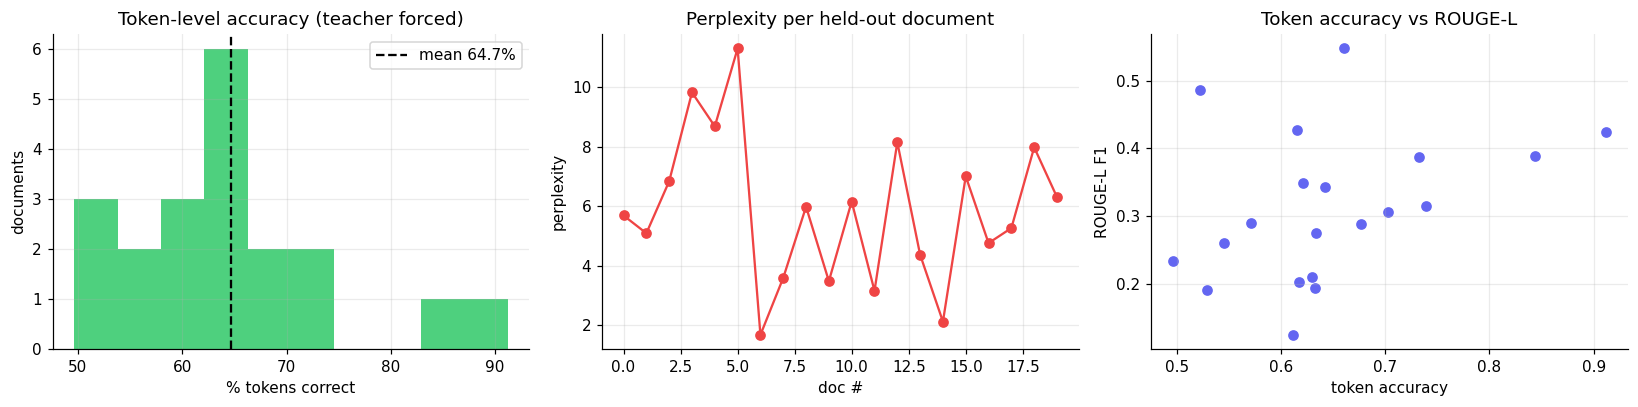


================ SUMMARY (mean over 20 held-out docs) ================


,ROUGE-1 F1,ROUGE-2 F1,ROUGE-L F1,Compression,Summary words,Sec/doc
method,,,,,,
Hybrid (recommended),0.392,0.248,0.312,0.060,69.55,3.406
Abstractive only,0.368,0.234,0.306,0.055,61.00,3.184
Extractive only,0.360,0.172,0.232,0.380,449.35,0.004


Token accuracy: 64.7%  |  Loss: 1.670  |  Perplexity: 5.88
Saved graphs + CSVs to /content/graphs


In [8]:
# @title 📊 All evaluation graphs (ROUGE, token accuracy, perplexity, compression, speed, training curves)
import os, json, math, time
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
import torch
from rouge_score import rouge_scorer

# ------------- settings -------------
N_PLOT  = min(N_EVAL, 20)      # held-out documents to evaluate (more = slower, smoother graphs)
COMPARE = METHODS              # Hybrid vs Abstractive-only vs Extractive-only
OUT_DIR = "/content/graphs"
DOWNLOAD_GRAPHS_ZIP = False
# ------------------------------------
os.makedirs(OUT_DIR, exist_ok=True)
plt.rcParams.update({"figure.dpi": 110, "axes.grid": True, "grid.alpha": .25,
                     "axes.spines.top": False, "axes.spines.right": False, "font.size": 10})
COL = {"Hybrid (recommended)": "#6366f1", "Abstractive only": "#06b6d4", "Extractive only": "#f59e0b"}
short = lambda m: m.split(" (")[0]

tokenizer, model = get_model()
corpus = load_corpus()
held = corpus.select(range(max(0, len(corpus) - N_PLOT), len(corpus)))
scorer = rouge_scorer.RougeScorer(["rouge1", "rouge2", "rougeL"], use_stemmer=True)

# ---------- 1) generation metrics for every method ----------
rec = []
for i, ex in enumerate(held):
    src, ref = ex[TEXT_COL], ex[SUMMARY_COL]
    for m in COMPARE:
        t0 = time.time()
        pred, _ = summarize_document(src, m, 256, 50)
        dt = time.time() - t0
        r = {"doc": i, "method": m, "time_s": dt, "src_words": len(src.split()),
             "ref_words": len(ref.split()), "sum_words": len(pred.split()),
             "compression": len(pred.split()) / max(1, len(src.split()))}
        for k, v in scorer.score(ref, pred).items():
            r[f"{k}_p"], r[f"{k}_r"], r[f"{k}_f"] = v.precision, v.recall, v.fmeasure
        rec.append(r)
    print(f"  evaluated {i+1}/{len(held)}", end="\r")
df = pd.DataFrame(rec)

# ---------- 2) teacher-forced token accuracy / loss / perplexity ----------
tf = []
for ex in held:
    enc = tokenizer(ex[TEXT_COL], return_tensors="pt", max_length=MAX_INPUT_TOKENS, truncation=True).to(DEVICE)
    lab = tokenizer(text_target=ex[SUMMARY_COL], return_tensors="pt", max_length=MAX_TARGET, truncation=True)["input_ids"].to(DEVICE)
    g = torch.zeros_like(enc["input_ids"]); g[:, 0] = 1
    with torch.inference_mode():
        o = model(input_ids=enc["input_ids"], attention_mask=enc["attention_mask"],
                  global_attention_mask=g, labels=lab)
    tf.append({"loss": o.loss.item(), "perplexity": math.exp(min(o.loss.item(), 20)),
               "token_acc": (o.logits.argmax(-1) == lab).float().mean().item()})
tfdf = pd.DataFrame(tf)

# ---------- 3) training log (saved with the model zip) ----------
log = None
for p in [os.path.join(MODEL_DIR or "", "training_log.json"), os.path.join(SAVE_DIR, "training_log.json")]:
    if os.path.exists(p):
        log = json.load(open(p)); break

def save(fig, name):
    fig.tight_layout(); fig.savefig(f"{OUT_DIR}/{name}.png", bbox_inches="tight"); plt.show()

# ===================== FIGURE 1: training curves =====================
if log:
    steps = [l for l in log if "loss" in l]
    fig, ax = plt.subplots(1, 3, figsize=(15, 3.8))
    ax[0].plot([l["step"] for l in steps], [l["loss"] for l in steps], color="#6366f1", marker="o", ms=3)
    ax[0].set(title="Training loss", xlabel="step", ylabel="loss")
    lr = [l for l in steps if "learning_rate" in l]
    ax[1].plot([l["step"] for l in lr], [l["learning_rate"] for l in lr], color="#06b6d4")
    ax[1].set(title="Learning rate schedule", xlabel="step")
    gn = [l for l in steps if "grad_norm" in l]
    if gn: ax[2].plot([l["step"] for l in gn], [l["grad_norm"] for l in gn], color="#f59e0b")
    ax[2].set(title="Gradient norm", xlabel="step")
    fig.suptitle("Fine-tuning dynamics", y=1.03, fontweight="bold"); save(fig, "01_training_curves")
else:
    print("ℹ️ No training_log.json found - skipping training curves.")

# ===================== FIGURE 2: ROUGE comparison =====================
agg = df.groupby("method")[[c for c in df.columns if c.startswith("rouge")]].agg(["mean", "std"])
fig, ax = plt.subplots(1, 3, figsize=(16, 4.2))

metrics = ["rouge1_f", "rouge2_f", "rougeL_f"]; labels = ["ROUGE-1", "ROUGE-2", "ROUGE-L"]
w = 0.8 / len(COMPARE); x = np.arange(len(metrics))
for j, m in enumerate(COMPARE):
    means = [agg.loc[m, (k, "mean")] for k in metrics]; sds = [agg.loc[m, (k, "std")] for k in metrics]
    ax[0].bar(x + j * w, means, w, yerr=sds, capsize=3, label=short(m), color=COL.get(m))
ax[0].set_xticks(x + w * (len(COMPARE) - 1) / 2); ax[0].set_xticklabels(labels)
ax[0].set(title="ROUGE F1 by method (mean ± std)", ylim=(0, 1)); ax[0].legend()

main = COMPARE[0]
for j, kind in enumerate(["Precision", "Recall", "F1"]):
    sfx = "pfr"[j]
    ax[1].bar(x + j * 0.27, [agg.loc[main, (f"{k}_{sfx}", "mean")] for k in ["rouge1", "rouge2", "rougeL"]],
              0.27, label=kind)
ax[1].set_xticks(x + 0.27); ax[1].set_xticklabels(labels)
ax[1].set(title=f"Precision / Recall / F1 - {short(main)}", ylim=(0, 1)); ax[1].legend()

ax[2].remove(); axr = fig.add_subplot(1, 3, 3, projection="polar")
rad = ["rouge1_p", "rouge1_r", "rouge2_p", "rouge2_r", "rougeL_p", "rougeL_r"]
rl = ["R1-P", "R1-R", "R2-P", "R2-R", "RL-P", "RL-R"]
ang = np.linspace(0, 2 * np.pi, len(rad), endpoint=False).tolist(); ang += ang[:1]
for m in COMPARE:
    v = [agg.loc[m, (k, "mean")] for k in rad]; v += v[:1]
    axr.plot(ang, v, label=short(m), color=COL.get(m)); axr.fill(ang, v, alpha=.12, color=COL.get(m))
axr.set_xticks(ang[:-1]); axr.set_xticklabels(rl); axr.set_title("Metric radar", pad=18); axr.legend(loc="lower right", fontsize=8)
save(fig, "02_rouge_comparison")

# ===================== FIGURE 3: distributions & per-document heatmap =====================
fig, ax = plt.subplots(1, 3, figsize=(16, 4.2))
for m in COMPARE:
    ax[0].hist(df[df.method == m].rougeL_f, bins=10, alpha=.55, label=short(m), color=COL.get(m))
ax[0].set(title="ROUGE-L F1 distribution", xlabel="ROUGE-L F1", ylabel="documents"); ax[0].legend()

ax[1].boxplot([df[df.method == m].rougeL_f for m in COMPARE], labels=[short(m) for m in COMPARE], showmeans=True)
ax[1].set(title="ROUGE-L F1 spread per method", ylabel="F1")

hm = df[df.method == main].sort_values("doc")[["rouge1_f", "rouge2_f", "rougeL_f"]].copy()
hm["token_acc"] = tfdf["token_acc"].values[:len(hm)]
im = ax[2].imshow(hm.values, aspect="auto", cmap="viridis", vmin=0, vmax=1)
ax[2].set_xticks(range(4)); ax[2].set_xticklabels(["R-1", "R-2", "R-L", "TokAcc"])
ax[2].set(title=f"Per-document scores - {short(main)}", ylabel="held-out doc #"); ax[2].grid(False)
fig.colorbar(im, ax=ax[2], fraction=.046)
save(fig, "03_distributions_heatmap")

# ===================== FIGURE 4: compression, lengths, speed =====================
fig, ax = plt.subplots(2, 3, figsize=(16, 8))
for m in COMPARE:
    d = df[df.method == m]
    ax[0, 0].hist(d.compression * 100, bins=10, alpha=.55, label=short(m), color=COL.get(m))
    ax[0, 1].scatter(d.src_words, d.sum_words, s=28, alpha=.8, label=short(m), color=COL.get(m))
    ax[0, 2].scatter(d.ref_words, d.sum_words, s=28, alpha=.8, label=short(m), color=COL.get(m))
    ax[1, 0].scatter(d.sum_words, d.rougeL_f, s=28, alpha=.8, label=short(m), color=COL.get(m))
    if len(d) > 2:
        z = np.polyfit(d.sum_words, d.rougeL_f, 1); xs = np.linspace(d.sum_words.min(), d.sum_words.max(), 20)
        ax[1, 0].plot(xs, np.polyval(z, xs), color=COL.get(m), lw=1)
ax[0, 0].set(title="Compression ratio (summary / source)", xlabel="% of source words", ylabel="documents"); ax[0, 0].legend()
ax[0, 1].set(title="Source length vs summary length", xlabel="source words", ylabel="summary words")
mx = max(df.ref_words.max(), df.sum_words.max()); ax[0, 2].plot([0, mx], [0, mx], "k--", lw=1)
ax[0, 2].set(title="Reference vs predicted length (dashed = equal)", xlabel="reference words", ylabel="predicted words")
ax[1, 0].set(title="Summary length vs ROUGE-L (with trend)", xlabel="summary words", ylabel="ROUGE-L F1")
tm = df.groupby("method").time_s.agg(["mean", "std"]).loc[COMPARE]
ax[1, 1].bar([short(m) for m in COMPARE], tm["mean"], yerr=tm["std"], capsize=4, color=[COL.get(m) for m in COMPARE])
ax[1, 1].set(title="Latency per document", ylabel="seconds")
eff = df.groupby("method").apply(lambda d: d.rougeL_f.mean() / max(d.time_s.mean(), 1e-3)).loc[COMPARE]
ax[1, 2].bar([short(m) for m in COMPARE], eff, color=[COL.get(m) for m in COMPARE])
ax[1, 2].set(title="Efficiency: ROUGE-L per second", ylabel="F1 / s")
save(fig, "04_length_compression_speed")

# ===================== FIGURE 5: token accuracy & perplexity =====================
fig, ax = plt.subplots(1, 3, figsize=(15, 3.8))
ax[0].hist(tfdf.token_acc * 100, bins=10, color="#22c55e", alpha=.8)
ax[0].axvline(tfdf.token_acc.mean() * 100, color="k", ls="--", label=f"mean {tfdf.token_acc.mean()*100:.1f}%")
ax[0].set(title="Token-level accuracy (teacher forced)", xlabel="% tokens correct", ylabel="documents"); ax[0].legend()
ax[1].plot(tfdf.perplexity.values, marker="o", color="#ef4444")
ax[1].set(title="Perplexity per held-out document", xlabel="doc #", ylabel="perplexity")
ax[2].scatter(tfdf.token_acc.values, df[df.method == main].sort_values("doc").rougeL_f.values[:len(tfdf)], color="#6366f1")
ax[2].set(title="Token accuracy vs ROUGE-L", xlabel="token accuracy", ylabel="ROUGE-L F1")
save(fig, "05_token_accuracy_perplexity")

# ===================== summary table =====================
summary = df.groupby("method")[["rouge1_f", "rouge2_f", "rougeL_f", "compression", "sum_words", "time_s"]].mean().loc[COMPARE]
summary.columns = ["ROUGE-1 F1", "ROUGE-2 F1", "ROUGE-L F1", "Compression", "Summary words", "Sec/doc"]
print("\n================ SUMMARY (mean over %d held-out docs) ================" % len(held))
display(summary.round(3))
print(f"Token accuracy: {tfdf.token_acc.mean()*100:.1f}%  |  Loss: {tfdf.loss.mean():.3f}  |  Perplexity: {tfdf.perplexity.mean():.2f}")
df.to_csv(f"{OUT_DIR}/per_document_metrics.csv", index=False); summary.to_csv(f"{OUT_DIR}/summary_table.csv")
print("Saved graphs + CSVs to", OUT_DIR)

if DOWNLOAD_GRAPHS_ZIP:
    import shutil; from google.colab import files
    files.download(shutil.make_archive("/content/graphs", "zip", OUT_DIR))